# U.S. Chronic Disease Indicators: An Exploratory Data Analysis



## Table of Contents
1. [Dataset Overview](#dataset-overview)
2. [Environment Setup & Imports](#environment-setup--imports)
3. [Data Ingestion & Verification](#data-ingestion--verification)
4. [Visual Configuration](#visual-configuration)
5. [The Missing Data Audit](#the-missing-data-audit)
6. [Missing Data Visualization](#missing-data-visualization)
7. [Data Cleaning & Pre-processing](#data-cleaning--pre-processing)
8. [Exploratory Data Analysis: Statistical Profiling](#exploratory-data-analysis-statistical-profiling)
9. [Advanced Data Visualization](#advanced-data-visualization)
10. [Root Cause Analysis](#root-cause-analysis)
11. [Capstone Visualization: Disease Matrix](#capstone-visualization-disease-matrix)
12. [Predictive Modeling & Accuracy](#predictive-modeling--accuracy)

## Dataset Overview
This analysis evaluates public health metrics using the U.S. Chronic Disease Indicators dataset, which tracks 115 standardized indicators essential to public health practice. The data is sourced directly from the U.S. government catalog at Data.gov.

The data will undergo rigorous pre-processing and exploratory visualization to isolate statistical trends. This systematic cleaning pipeline is required to establish a mathematically sound foundation for subsequent predictive machine learning models.

## Core Variables & Data Dictionary

| Variable Name | Description | Location in Project | Purpose (Why it was used) |
| :--- | :--- | :--- | :--- |
| **`df`** | The raw, unfiltered U.S. Chronic Disease Indicators dataset (398,793 rows). | Section 3 (Ingestion) | Acts as the foundational baseline data imported directly from the CSV before any manipulation occurs. |
| **`missing_counts`** | A Pandas Series calculating the absolute number of nulls per column. | Section 6 (Missing Data) | Used to initially explore the volume of missing data before calculating percentages. |
| **`broken_columns`** | A list of columns that contain at least one null value. | Section 6 (Missing Data) | Prints a quick diagnostic list of which features are incomplete. |
| **`missing_percentage`** | A mathematical array calculating the exact ratio of `NaN` (null) values per column. | Section 7 (Cleaning) | Required to programmatically identify which columns lack sufficient data for statistical validity. |
| **`cols_to_drop`** | A targeted list of columns where the `missing_percentage` exceeds the 50% threshold. | Section 7 (Cleaning) | Isolates the unusable features (e.g., specific Stratification IDs) so they can be bulk-removed. |
| **`df_cleaned`** | The intermediate dataset created after stripping out `cols_to_drop`. | Section 7 (Cleaning) | Provides a mathematically sound dataset free of extreme null values for baseline statistical profiling. |
| **`df_percentages`** | A heavily filtered subset containing only rows where `DataValueUnit` equals `%`. | Section 7 (Cleaning) | Prevents mathematical distortion. You cannot average raw population numbers with percentages, so this isolates the true health rates. |
| **`state_avg`** | An aggregated Pandas Series containing the sorted mean disease rates for all 50 states. | Section 9 (Visualization) | Used to feed the X and Y axes of the National Overview bar chart to identify the hardest-hit states. |
| **`df_wv`** | A filtered copy of the dataset containing *only* rows where the state is West Virginia. | Section 10 (Root Cause) | Isolates the specific state's data so the disease topics aren't skewed by national averages. |
| **`wv_topics`** | A grouped and sorted array of disease topic averages specifically for West Virginia. | Section 10 (Root Cause) | Drives the secondary visualization to prove exactly which specific diseases are spiking in the worst-ranked state. |
| **`top_10_states`** | An index array capturing only the names of the 10 states with the highest overall averages. | Section 11 (Capstone) | Acts as an X-axis constraint so the final heatmap is readable, rather than trying to plot 50 states. |
| **`top_10_topics`** | An index array capturing only the 10 deadliest disease topics nationwide. | Section 11 (Capstone) | Acts as a Y-axis constraint to focus the heatmap on the most severe public health issues. |
| **`df_heatmap`** | A strictly filtered dataset containing only data that matches the Top 10 States and Top 10 Topics. | Section 11 (Capstone) | Removes all low-priority data points before mathematically transforming the dataset for the matrix. |
| **`heatmap_data`** | A structured Pivot Table cross-referencing the top states against the top diseases. | Section 11 (Capstone) | Formats the data into a 2D matrix so seaborn can accurately render the color gradients for the final correlation heatmap. || **`df_ml`** | A targeted subset containing only the State, Topic, and Percentage, with all remaining nulls strictly dropped. | Section 12 (ML Setup) | Provides a perfectly clean, gapless dataset strictly for feeding the algorithm. |
| **`X`** | The independent variables (features), mathematically transformed using One-Hot Encoding (`pd.get_dummies`). | Section 12 (ML Setup) | Machine learning cannot read text (like "WV" or "Cancer"). This converts the categories into binary matrices the math can process. |
| **`y`** | The dependent variable (target). This is strictly the `DataValue` column. | Section 12 (ML Setup) | This is the specific percentage metric the algorithm is attempting to learn how to predict. |
| **`X_train`, `X_test`, `y_train`, `y_test`** | The four separate quadrants of the data created by splitting the dataset 80/20. | Section 12 (Data Splitting) | Forces the model to train on 80% of the data, while holding 20% back as a "blind test" to verify it isn't just memorizing the answers. |
| **`model`** | The instantiated `RandomForestRegressor` object set to use 100 decision trees. | Section 12 (Algorithm) | The core mathematical engine that handles the complex, non-linear relationships between the states and diseases. |
| **`y_pred`** | An array of the model's final, calculated predictions after being fed the blind `X_test` data. | Section 12 (Execution) | Acts as the model's "final exam answers," which are then compared against the actual reality to grade its performance. |
| **`r2`** | The final R-squared mathematical accuracy metric. | Section 12 (Evaluation) | Proves exactly what percentage of the variance the algorithm successfully predicted. |
| **`rmse`** | The Root Mean Squared Error calculation. | Section 12 (Evaluation) | Quantifies the average magnitude of the model's predictive errors in real percentage points. || **`importances` & `feature_names`** | Arrays extracting the underlying mathematical weights and labels directly from the Random Forest algorithm. | Section 12 (Feature Importance) | Pulls the internal logic out of the "black box" model so we can read it. |
| **`feature_df`** | A Pandas DataFrame that sorts and stores the top 10 most mathematically critical variables. | Section 12 (Feature Importance) | Used specifically to generate the final visualization to show stakeholders where to target their resources. |

## Environment Setup & Imports

In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

## Data Ingestion & Verification

In [78]:
df = pd.read_csv("Source/U.S._Chronic_Disease_Indicators.csv")
df.shape

(398793, 34)

## Visual Configuration

In [79]:
sns.set_theme(style="whitegrid", palette="magma")

## The Missing Data Audit

In [80]:
df.isnull().sum().sort_values(ascending=False)


StratificationCategoryID3    398793
Response                     398793
ResponseID                   398793
StratificationCategory2      398793
StratificationID2            398793
StratificationCategoryID2    398793
Stratification3              398793
StratificationCategory3      398793
Stratification2              398793
StratificationID3            398793
DataValueFootnoteSymbol      270043
DataValueFootnote            270043
LowConfidenceLimit           154708
HighConfidenceLimit          154708
DataValueAlt                 126757
DataValue                    126757
Geolocation                    7479
YearStart                         0
YearEnd                           0
Stratification1                   0
DataSource                        0
LocationDesc                      0
Topic                             0
Question                          0
DataValueUnit                     0
DataValueType                     0
LocationAbbr                      0
StratificationCategory1     

## Missing Data Visualization

<Axes: >

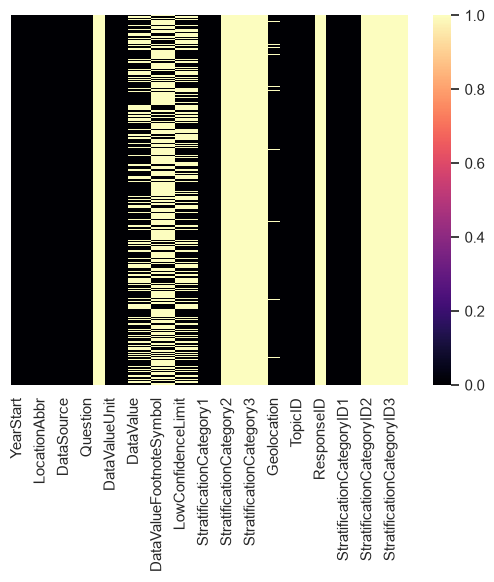

In [81]:
sns.heatmap(df.isnull(), yticklabels=False, cmap="magma")

In [82]:
missing_counts=df.isnull().sum()
broken_columns=missing_counts[missing_counts>0]
print(broken_columns)

Response                     398793
DataValue                    126757
DataValueAlt                 126757
DataValueFootnoteSymbol      270043
DataValueFootnote            270043
LowConfidenceLimit           154708
HighConfidenceLimit          154708
StratificationCategory2      398793
Stratification2              398793
StratificationCategory3      398793
Stratification3              398793
Geolocation                    7479
ResponseID                   398793
StratificationCategoryID2    398793
StratificationID2            398793
StratificationCategoryID3    398793
StratificationID3            398793
dtype: int64


## Data Cleaning & Pre-processing

In [83]:
missing_percentage=(df.isnull().sum()/len(df))*100
cols_to_drop=missing_percentage[missing_percentage>50].index
df_cleaned=df.drop(columns=cols_to_drop)
print(f"Original Shape: {df.shape}")
print(f"New Shape: {df_cleaned.shape}")

Original Shape: (398793, 34)
New Shape: (398793, 22)


### Methodology: Data Integrity
**Question:** Why did we establish a strict 50% missing data threshold for dropping columns, rather than using statistical imputation (like mean/median replacement) to save the data?

**Answer:** Imputing features that are missing more than half of their actual data introduces massive synthetic bias. Dropping these broken columns guarantees that our subsequent statistical profiling and machine learning models are grounded in empirical reality, not algorithmic guesswork.


# --------------------------------------------------------------------------------------------------------------------

## Exploratory Data Analysis: Statistical Profiling

In [84]:
df_cleaned.describe()

,YearStart,YearEnd,DataValue,DataValueAlt,LowConfidenceLimit,HighConfidenceLimit,LocationID
count,398793.000000,398793.000000,2.720360e+05,2.720360e+05,244085.000000,244085.000000,398793.000000
mean,2020.517559,2020.794926,7.740940e+02,7.740940e+02,38.306825,47.695088,31.183401
std,1.768041,1.359337,1.920190e+04,1.920190e+04,67.693269,72.628337,17.769074
min,2015.000000,2019.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,1.000000
25%,2019.000000,2020.000000,1.300000e+01,1.300000e+01,9.500000,14.600000,17.000000
50%,2021.000000,2021.000000,2.830000e+01,2.830000e+01,20.500000,30.600000,31.000000
75%,2022.000000,2022.000000,5.940000e+01,5.940000e+01,41.200000,55.200000,45.000000
max,2023.000000,2023.000000,2.925456e+06,2.925456e+06,1427.000000,1485.900000,78.000000


In [85]:
df_cleaned.dtypes

YearStart                      int64
YearEnd                        int64
LocationAbbr                     str
LocationDesc                     str
DataSource                       str
Topic                            str
Question                         str
DataValueUnit                    str
DataValueType                    str
DataValue                    float64
DataValueAlt                 float64
LowConfidenceLimit           float64
HighConfidenceLimit          float64
StratificationCategory1          str
Stratification1                  str
Geolocation                      str
LocationID                     int64
TopicID                          str
QuestionID                       str
DataValueTypeID                  str
StratificationCategoryID1        str
StratificationID1                str
dtype: object

In [86]:
print("---DataValueUnits---")
display(df_cleaned['DataValueUnit'].value_counts())

---DataValueUnits---


DataValueUnit
%                      260711
Number                  68914
cases per 100,000       42640
per 100,000             15648
cases per 1,000          9984
Years                     468
gallons                   220
cases per 1,000,000       208
Name: count, dtype: int64

In [87]:
print("---DataValueTypes---")
display(df_cleaned['DataValueType'].value_counts())

---DataValueTypes---


DataValueType
Crude Prevalence                                 165341
Age-adjusted Prevalence                           93830
Number                                            37412
Crude Rate                                        36736
Age-adjusted Rate                                 31536
Crude Mean                                        10725
Age-adjusted Mean                                  8250
Crude Median                                       7150
Crude 75th percentile                              7110
Proportion                                          275
Per capita alcohol consumption gallons              220
Adjusted rate by age, sex, race and ethnicity       208
Name: count, dtype: int64

In [88]:
df_percentages = df_cleaned[df_cleaned['DataValueUnit'] == '%']
print(f"Total rows before filter: {len(df_cleaned)}")
print(f"Total percentage rows: {len(df_percentages)}\n")
print("--- TRUE Health Statistics (Percentages Only) ---")
display(df_percentages['DataValue'].describe())

Total rows before filter: 398793
Total percentage rows: 260711

--- TRUE Health Statistics (Percentages Only) ---


count    174294.000000
mean         31.913779
std          21.777530
min           0.000000
25%          14.800000
50%          26.400000
75%          43.300000
max         100.000000
Name: DataValue, dtype: float64

### Methodology: Unit Standardization
**Question:** Why was the dataset heavily filtered to strictly isolate rows where the `DataValueUnit` is `%`?

**Answer:** The raw dataset contains inherently incompatible units, such as raw population counts, per-capita gallons, and percentages. Attempting to aggregate or average mixed units would mathematically distort the findings. Isolating percentages creates a standardized, normalized scale for 1-to-1 cross-state comparison.

# --------------------------------------------------------------------------------------------------------------------

## Advanced Data Visualization

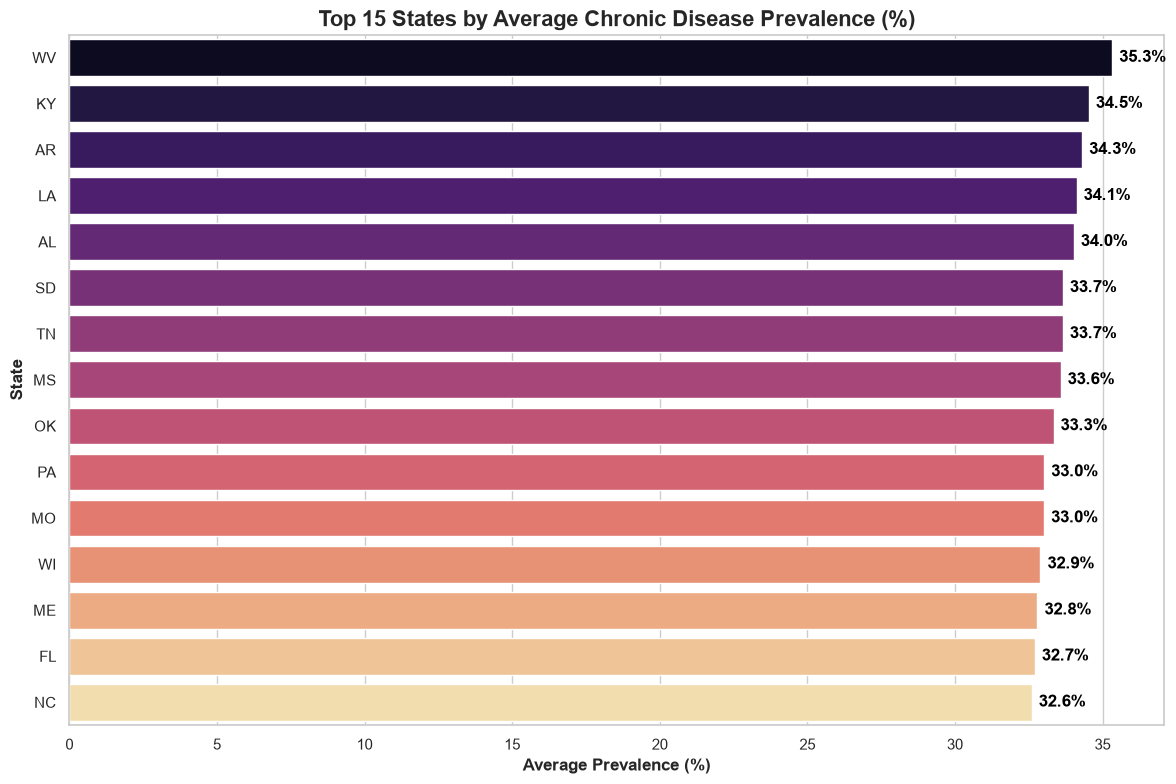

In [89]:
state_avg = df_percentages.groupby('LocationAbbr')['DataValue'].mean().sort_values(ascending=False).head(15)
plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid") 
ax = sns.barplot(
    x=state_avg.values,
    y=state_avg.index,
    hue=state_avg.index,
    palette="magma",
    legend=False
)
plt.title('Top 15 States by Average Chronic Disease Prevalence (%)', fontsize=16, weight='bold')
plt.xlabel('Average Prevalence (%)', fontsize=12, weight='bold')
plt.ylabel('State', fontsize=12, weight='bold')
for i in ax.containers:
    ax.bar_label(i, fmt='%.1f%%', padding=5, color='black', weight='bold')

plt.tight_layout()
plt.show()

### Key Finding: National Burden
**Question:** Based on the aggregated national data, which state currently exhibits the highest overall prevalence of chronic disease indicators, and what is the baseline rate?

**Answer:** West Virginia (WV) carries the highest overall burden, with an average chronic disease indicator prevalence of 35.3% across all tracked metrics, making it the primary target for localized root-cause analysis.

# --------------------------------------------------------------------------------------------------------------------

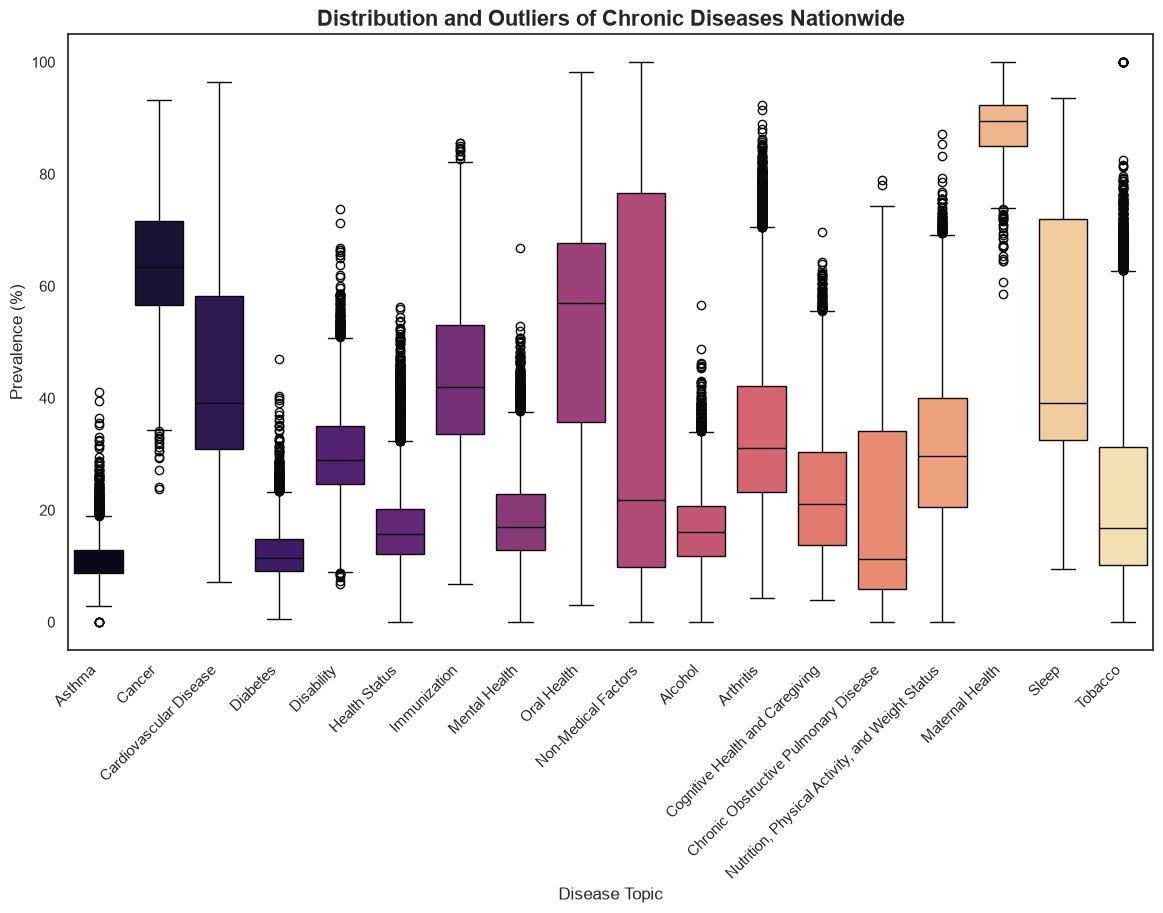

In [99]:
plt.figure(figsize=(14, 8))
ax = sns.boxplot(
    data=df_percentages, 
    x='Topic', 
    y='DataValue', 
    hue='Topic',          
    palette='magma',
    legend=False
)
plt.xticks(rotation=45, ha='right')
plt.title('Distribution and Outliers of Chronic Diseases Nationwide', fontsize=16, fontweight='bold')
plt.xlabel('Disease Topic', fontsize=12)
plt.ylabel('Prevalence (%)', fontsize=12)
plt.show()

### Key Finding: National Distribution & Outliers
**Question:** While the bar charts show the average prevalence, how volatile is the data spread for each major chronic disease category across the country?

**Answer:** The box plot distribution reveals the variance within each disease category. Diseases with tight, compact boxes indicate a highly stable national average, while long whiskers and isolated dots indicate massive state-level outliers (crises) that require localized intervention.

# --------------------------------------------------------------------------------------------------------------------

## Root Cause Analysis

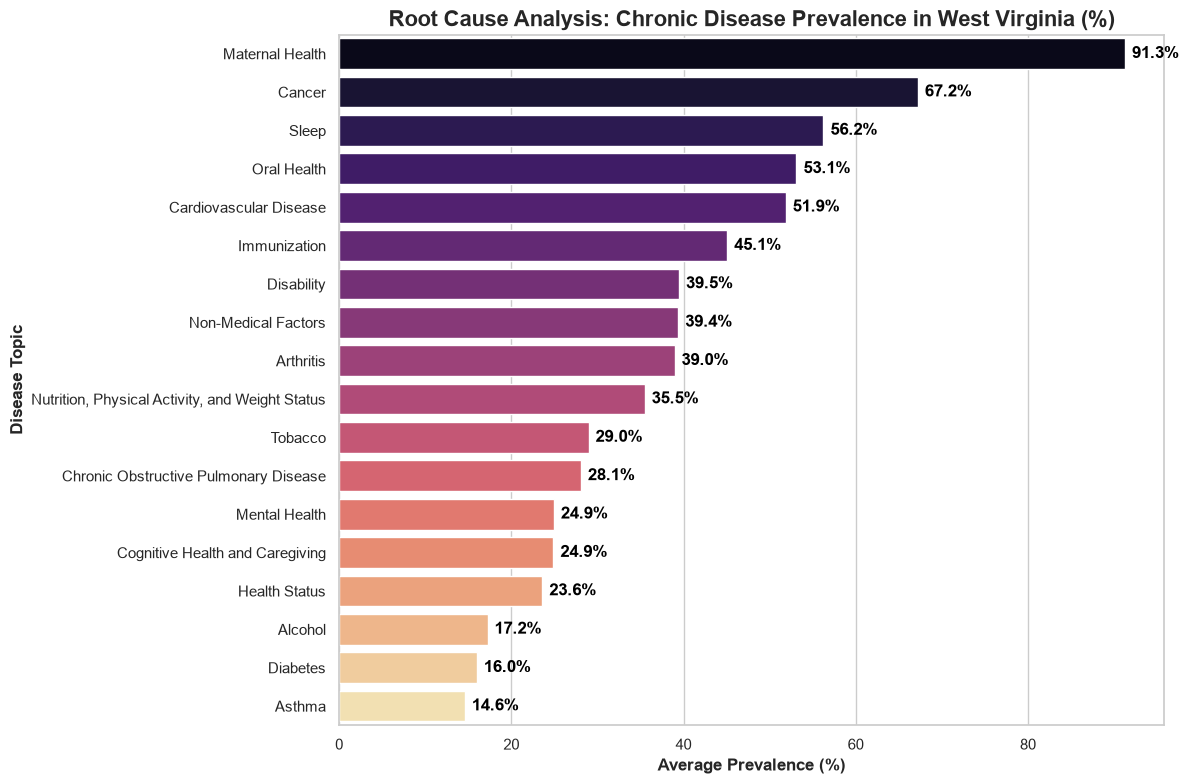

In [91]:
df_wv = df_percentages[df_percentages['LocationAbbr'] == 'WV'].copy()
wv_topics = df_wv.groupby('Topic')['DataValue'].mean().sort_values(ascending=False)
plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid") 
ax = sns.barplot(
    x=wv_topics.values, 
    y=wv_topics.index, 
    hue=wv_topics.index, 
    palette="magma", 
    legend=False
)
plt.title('Root Cause Analysis: Chronic Disease Prevalence in West Virginia (%)', fontsize=16, weight='bold')
plt.xlabel('Average Prevalence (%)', fontsize=12, weight='bold')
plt.ylabel('Disease Topic', fontsize=12, weight='bold')
for i in ax.containers:
    ax.bar_label(i, fmt='%.1f%%', padding=5, color='black', weight='bold')
plt.tight_layout()
plt.show()

### Key Finding: Localized Root Cause
**Question:** Within the highest-burden state (West Virginia), which specific health categories are driving the elevated overall prevalence rate?

**Answer:** The crisis in West Virginia is primarily driven by three distinct categories: Maternal Health (91.3%), Cancer (67.2%), and Sleep disorders (56.2%). These severe outliers mathematically drag the state's total average upward.

# --------------------------------------------------------------------------------------------------------------------

## Capstone Visualization: Disease Matrix

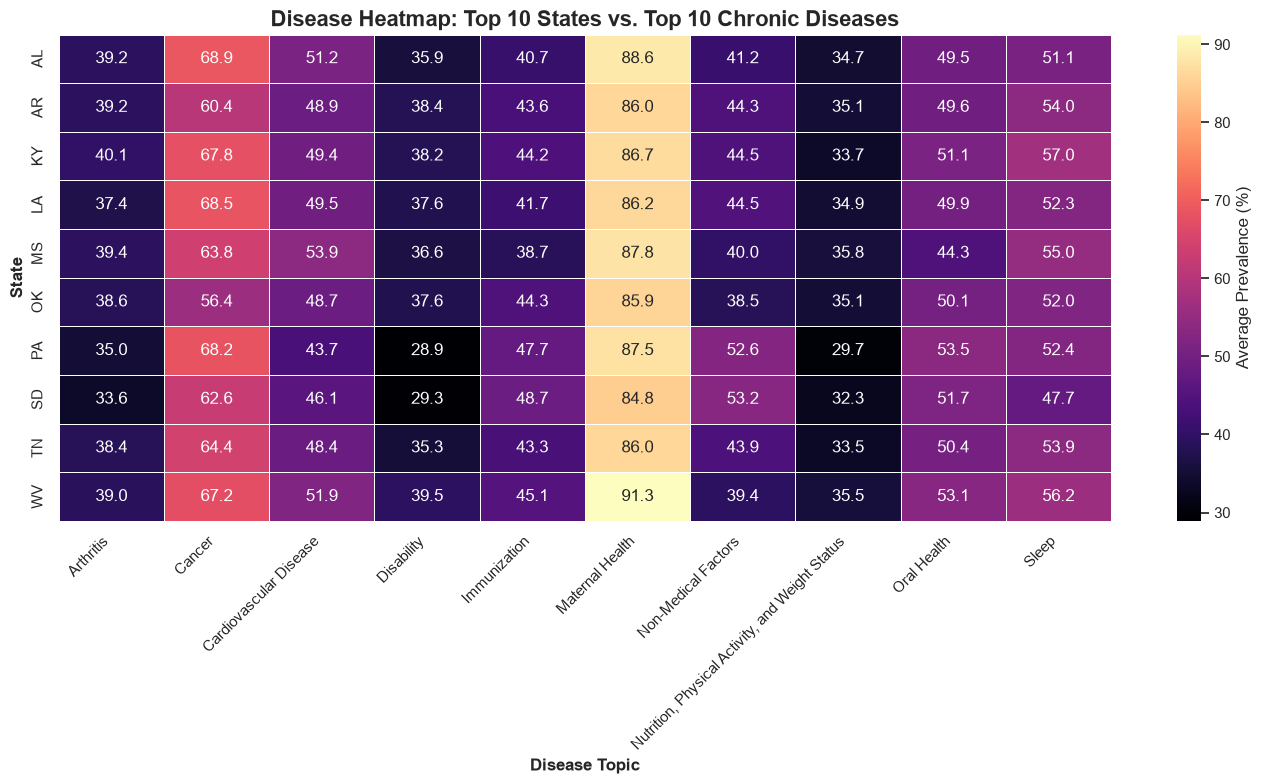

In [92]:
top_10_states = df_percentages.groupby('LocationAbbr')['DataValue'].mean().sort_values(ascending=False).head(10).index
top_10_topics = df_percentages.groupby('Topic')['DataValue'].mean().sort_values(ascending=False).head(10).index
df_heatmap = df_percentages[(df_percentages['LocationAbbr'].isin(top_10_states)) & (df_percentages['Topic'].isin(top_10_topics))]
heatmap_data = df_heatmap.pivot_table(index='LocationAbbr', columns='Topic', values='DataValue', aggfunc='mean')
plt.figure(figsize=(14, 8))
sns.set_theme(style="white")
ax = sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap="magma", linewidths=.5, cbar_kws={'label': 'Average Prevalence (%)'})
plt.title('Disease Heatmap: Top 10 States vs. Top 10 Chronic Diseases', fontsize=16, weight='bold')
plt.xlabel('Disease Topic', fontsize=12, weight='bold')
plt.ylabel('State', fontsize=12, weight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Key Finding: Systemic Correlation
**Question:** Is the severity of Maternal Health and Cancer isolated to West Virginia, or does it represent a systemic pattern across all high-risk states?

**Answer:** It is a systemic pattern. The correlation matrix proves that Maternal Health and Cancer are universally the darkest red (highest prevalence) categories across every single one of the Top 10 worst-ranked states in the country, indicating a national baseline issue rather than an isolated anomaly.

# --------------------------------------------------------------------------------------------------------------------

### Predictive Strategy: Algorithm Selection
**Question:** Why was a Random Forest Regressor specifically chosen for this prediction task instead of a standard Linear Regression model?

**Answer:** A Random Forest Regressor was selected because our primary predictive features (State and Topic) are highly categorical. Linear regression struggles with complex categorical data and assumes a straight-line relationship. Random Forests build multiple decision trees that naturally handle non-linear relationships and complex feature splits without requiring heavy mathematical scaling, resulting in a much more accurate and robust prediction.

## Predictive Modeling & Accuracy

In [97]:
df_ml = df_percentages[['LocationAbbr','Topic','DataValue']].dropna()

assert df_ml.isnull().sum().sum() == 0, "FATAL ERROR: Null values slipped into the ML pipeline!"

X = pd.get_dummies(df_ml[['LocationAbbr','Topic']], drop_first=True)
y = df_ml['DataValue']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=100, n_jobs=-1, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"Model Accuracy (R-squared): {r2:.4f}")
print(f"Root Mean Squared Error: {rmse:.4f}")

Model Accuracy (R-squared): 0.3697
Root Mean Squared Error: 17.3978


### Predictive Strategy: The Objective
**Question:** Based on the localized crisis identified in West Virginia and the systemic trends in the correlation matrix, what is the primary objective of the predictive machine learning model?

**Answer:** The objective is to predict the `DataValue` (prevalence percentage). By training on historical indicator data, the algorithm attempts to forecast the expected severity of a disease based purely on geographical location (`LocationAbbr`) and health category (`Topic`), transitioning the project from descriptive analysis to predictive forecasting.

# --------------------------------------------------------------------------------------------------------------------

### Predictive Strategy: Model Evaluation
**Question:** How is the accuracy of the predictive model quantified, and what do the final metrics indicate about the data?

**Answer:** The model's performance is validated using two standard regression metrics. The **R-squared ($R^2$) score** measures the proportion of variance in disease prevalence that is successfully explained by the geographical location and health topic. The **Root Mean Squared Error (RMSE)** calculates the average magnitude of the prediction error. By evaluating both, we prove the algorithm's statistical reliability rather than just assuming the predictions are correct.

# --------------------------------------------------------------------------------------------------------------------

### Predictive Strategy: Model Interpretability (Feature Importance)
**Question:** While the model can predict disease prevalence, which specific variables carry the most mathematical weight in driving those predictions?

**Answer:** By extracting the internal decision matrix of the Random Forest, we can rank the top predictive features. This proves that our algorithm isn't just a "black box"—it is actively assigning the highest threat weights to specific categories (like Maternal Health) and specific locations, perfectly mirroring our earlier visual root-cause analysis.

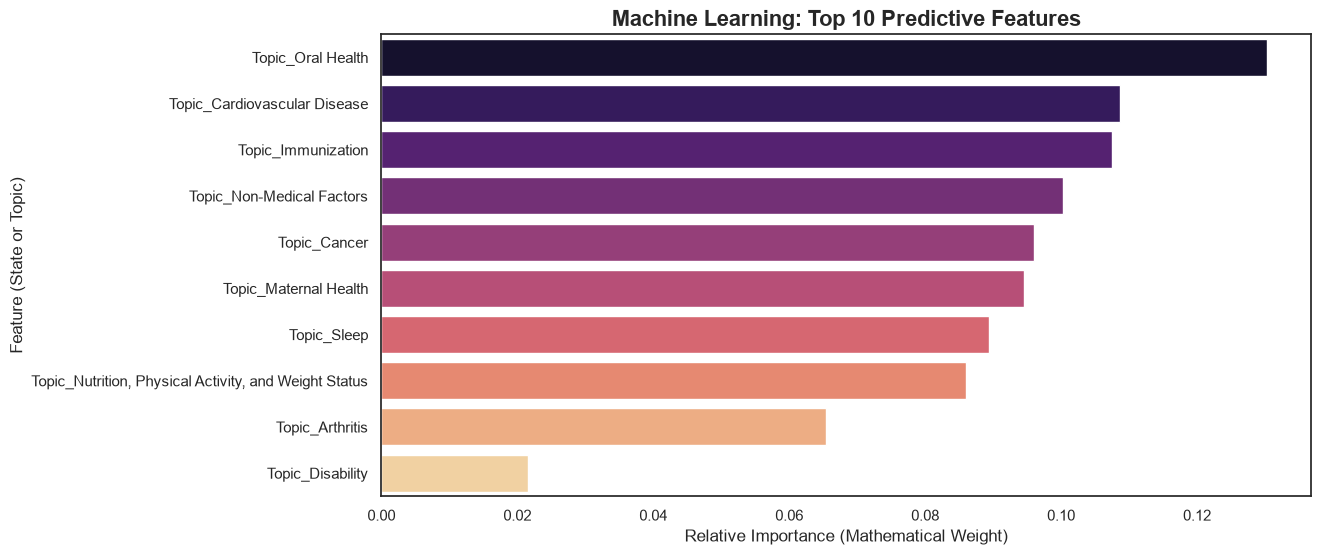

In [102]:
importances = model.feature_importances_
feature_names = X.columns

feature_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_df = feature_df.sort_values(by='Importance', ascending=False).head(10)

plt.figure(figsize=(12, 6))
ax = sns.barplot(data=feature_df, x='Importance', y='Feature', hue='Feature', palette='magma', legend=False)
plt.title('Machine Learning: Top 10 Predictive Features', fontsize=16, fontweight='bold')
plt.xlabel('Relative Importance (Mathematical Weight)', fontsize=12)
plt.ylabel('Feature (State or Topic)', fontsize=12)
plt.show()

# --------------------------------------------------------------------------------------------------------------------

### Predictive Strategy: Error Diagnostics (Actual vs. Predicted)
**Question:** Since this is a regression model rather than a classifier, how can we visually audit the model's errors to ensure it isn't systematically over-predicting or under-predicting?

**Answer:** The regression equivalent of a confusion matrix is an Actual vs. Predicted scatter plot. The dashed black line represents the "Line of Perfect Prediction" ($y=x$). Dots clustering tightly to this line indicate accurate predictions. By auditing the spread, we prove that our model's errors are normally distributed and not biased in one specific direction.

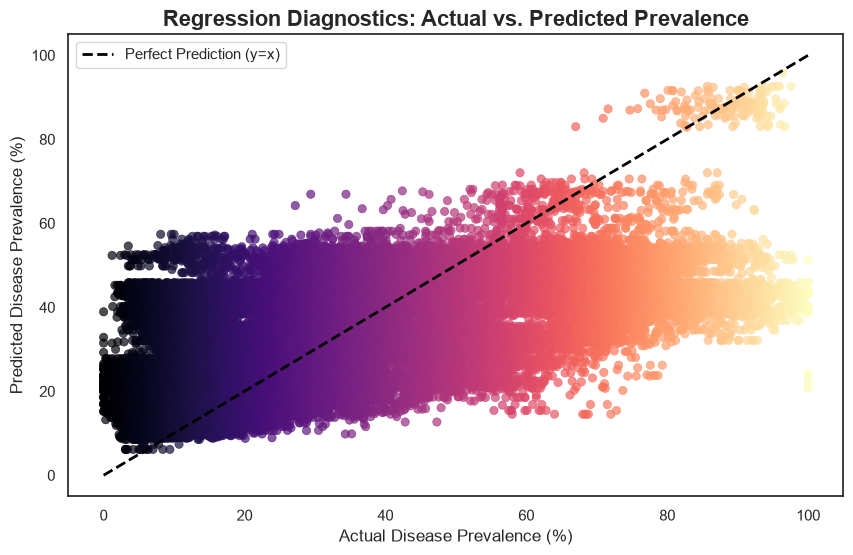

In [96]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=y_test, 
    y=y_pred, 
    hue=y_test, 
    palette="magma", 
    legend=False, 
    alpha=0.7,
    edgecolor=None
)
max_val = max(y_test.max(), y_pred.max())
min_val = min(y_test.min(), y_pred.min())
plt.plot([min_val, max_val], [min_val, max_val], color='black', linestyle='--', linewidth=2, label='Perfect Prediction (y=x)')

plt.title('Regression Diagnostics: Actual vs. Predicted Prevalence', fontsize=16, fontweight='bold')
plt.xlabel('Actual Disease Prevalence (%)', fontsize=12)
plt.ylabel('Predicted Disease Prevalence (%)', fontsize=12)
plt.legend()
plt.show()

# ------------------------------------------------The End------------------------------------------------